# Dependencies

In [20]:
%pip install -q pretty_midi torchinfo

Note: you may need to restart the kernel to use updated packages.


In [21]:
from pathlib import Path
import os
import time
import traceback
import math
import h5py
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pretty_midi
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchinfo import summary
from tqdm.auto import tqdm

# Config

In [22]:
# Paths
KAGGLE_BASE = Path("/kaggle/input/datasets/alonhaviv/the-maestro-dataset-v3-0-0/maestro-v3.0.0")
WORKING_DIR = Path("/kaggle/working")
CSV_PATH = KAGGLE_BASE / "maestro-v3.0.0.csv"
OUTPUT_PATH = WORKING_DIR / "maestro_train_chunked.h5"
VAL_PATH = WORKING_DIR / "maestro_val_chunked.h5"

# Audio / CQT
SR = 44_100
HOP = 384
FPS = SR / HOP
BINS_PER_OCTAVE = 36
N_OCTAVES = 7
N_BINS = BINS_PER_OCTAVE * N_OCTAVES
FMIN = librosa.note_to_hz("A0")

# MIDI label matrix
MIDI_LO = 21  # A0
MIDI_HI = 108 # C8
N_PITCHES = MIDI_HI - MIDI_LO + 1
CH_ACTIVE = 0
CH_ONSET = 1
CH_VEL = 2
N_LABEL_CHANNELS = 3

# Dataset build
SPLIT = "train"
LIMIT = 10  # Use an integer for smoke tests, or None for the full split.
CHUNK_FRAMES = 384
CHUNK_HOP_FRAMES = 384
ONSET_RADIUS = 1
KEEP_INCOMPLETE = False
MAX_GAP_FRAMES = 43
TARGET_MODE = "active_onset"
TARGET_CHANNELS = ("active", "onset")
N_TARGET_CHANNELS = len(TARGET_CHANNELS)

    # DataLoader
BATCH_SIZE = 8
NUM_WORKERS = 2

# Model / training
D_MODEL = 128
N_HEADS = 4
N_LAYERS = 4
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 30
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Loss
active_pos_weight = 15.0
onset_pos_weight = 25.0
onset_loss_weight = 1.0
sustain_onset_neg_weight = 2

# MIDI label helpers

In [23]:
"""
Convert clean MIDI files <-> (T, 88, 3) label matrices aligned to a CQT grid.

Matrix layout
-------------
  Y[t, i, 0]  active   – 1.0 while note i is held at frame t
  Y[t, i, 1]  onset    – 1.0 only at the first frame of each note
  Y[t, i, 2]  velocity – velocity / 127.0 while note is active, else 0.0

Pitch axis
----------
  index i = midi_pitch - MIDI_LO   (i=0 → A0=21, i=87 → C8=108)

Time axis
---------
  frame = round(time_seconds * SR / HOP)
  SR  = 44_100
  HOP = 384
  FPS = SR / HOP ≈ 114.84 frames per second

Inversion loss
--------------
  Sub-frame timing is lost (max ≈ ±4.35 ms at HOP=384). Everything else is exact.
"""

def seconds_to_frame(t: float) -> int:
    """Convert a time in seconds to the nearest CQT frame index."""
    return int(round(t * FPS))
 
 
def frame_to_seconds(f: int) -> float:
    """Convert a CQT frame index back to its centre time in seconds."""
    return f / FPS
 
 
def _pitch_to_idx(pitch: int) -> int | None:
    """Return matrix column for a MIDI pitch, or None if out of range."""
    if MIDI_LO <= pitch <= MIDI_HI:
        return pitch - MIDI_LO
    return None
 
 
# ── forward pass: MIDI → matrix ──────────────────────────────────────────────
 
def midi_to_label_matrix(
    midi_path: str,
    n_frames: int | None = None,
    pad_frames: int = 0,
    offset_seconds: float = 0.0,
) -> np.ndarray:
    """
    Load a MIDI file and return a (T, 88, 3) float32 label matrix.
 
    Parameters
    ----------
    midi_path : str
        Path to the .mid / .midi file.
    n_frames : int, optional
        Force the time axis to exactly this length.  If None, the length is
        derived from the last note-off event.
    pad_frames : int
        Extra frames appended after the last event (only used when n_frames
        is None).
    offset_seconds : float
        Shift all MIDI events forward in time by this many seconds before
        converting to frames.  Use this to align a MIDI that starts at t=0
        with a WAV that has a lead-in silence (e.g. offset = first_note_time).
 
    Returns
    -------
    Y : np.ndarray, shape (T, 88, 3), dtype float32
    """
    pm = pretty_midi.PrettyMIDI(midi_path)
 
    # Determine matrix length
    if n_frames is not None:
        T = n_frames
    else:
        end_time = pm.get_end_time() + offset_seconds
        T = seconds_to_frame(end_time) + 1 + pad_frames
 
    Y = np.zeros((T, N_PITCHES, N_LABEL_CHANNELS), dtype=np.float32)
 
    for instrument in pm.instruments:
        if instrument.is_drum:
            continue
        for note in instrument.notes:
            idx = _pitch_to_idx(note.pitch)
            if idx is None:
                continue
 
            f_on  = min(seconds_to_frame(note.start + offset_seconds), T - 1)
            f_off = min(seconds_to_frame(note.end   + offset_seconds), T - 1)
 
            # When onset and offset land on the same frame, keep at least 1
            if f_off <= f_on:
                f_off = f_on + 1
            f_off = min(f_off, T)          # exclusive upper bound for slice
 
            vel_norm = note.velocity / 127.0
 
            Y[f_on:f_off, idx, CH_ACTIVE] = 1.0
            Y[f_on,        idx, CH_ONSET]  = 1.0
            Y[f_on:f_off,  idx, CH_VEL]   = vel_norm
 
    return Y
 

    
# ── inverse pass: matrix → MIDI ──────────────────────────────────────────────
 
def label_matrix_to_midi(
    Y: np.ndarray,
    output_path: str | None = None,
    onset_threshold: float = 0.5,
    active_threshold: float = 0.5,
    tempo: float = 120.0,
    program: int = 0,
) -> pretty_midi.PrettyMIDI:
    """
    Reconstruct a PrettyMIDI object from a (T, 88, 3) label matrix.
 
    The reconstruction algorithm
    ─────────────────────────────
    For each pitch i:
      • A note starts at frame t when onset[t,i] > threshold  (or when
        active[t,i] rises after being 0, as a fallback).
      • The note ends at the first frame where active[t,i] drops to 0,
        or at the last frame T if it never drops.
      • Velocity is the mean of vel[t,i] over the active span, re-scaled
        to 0–127 and clamped to [1, 127].
 
    Parameters
    ----------
    Y : np.ndarray, shape (T, 88, 3)
    output_path : str, optional
        If given, write the MIDI to this path.
    onset_threshold : float
        Minimum value in CH_ONSET to declare a note start.
    active_threshold : float
        Minimum value in CH_ACTIVE to consider a note held.
    tempo : float
        BPM written into the output file (default 120).
    program : int
        General MIDI program number for the single output instrument.
 
    Returns
    -------
    pm : pretty_midi.PrettyMIDI
    """
    if Y.ndim != 3 or Y.shape[1] != N_PITCHES or Y.shape[2] != N_LABEL_CHANNELS:
        raise ValueError(f"Expected shape (T, {N_PITCHES}, {N_LABEL_CHANNELS}), got {Y.shape}")
 
    T = Y.shape[0]
    active  = Y[:, :, CH_ACTIVE] >= active_threshold   # (T, 88) bool
    onset   = Y[:, :, CH_ONSET]  >= onset_threshold    # (T, 88) bool
    vel_mat = Y[:, :, CH_VEL]                           # (T, 88) float
 
    pm = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    instrument = pretty_midi.Instrument(program=program)
 
    for i in range(N_PITCHES):
        pitch = i + MIDI_LO
        t = 0
        while t < T:
            # Find a note start: prefer explicit onset, fall back to
            # active rising edge (handles matrices without onset channel).
            if onset[t, i] or (active[t, i] and (t == 0 or not active[t - 1, i])):
                note_start = t
                # Advance until the note ends: stop at active=0 OR a new
                # onset on the same pitch (re-attack without a gap).
                t_end = t + 1
                while t_end < T and active[t_end, i] and not onset[t_end, i]:
                    t_end += 1
 
                # Mean velocity over the held frames
                vel_raw = vel_mat[note_start:t_end, i].mean()
                velocity = int(np.clip(round(vel_raw * 127), 1, 127))
 
                note = pretty_midi.Note(
                    velocity=velocity,
                    pitch=pitch,
                    start=frame_to_seconds(note_start),
                    end=frame_to_seconds(t_end),
                )
                instrument.notes.append(note)
                t = t_end   # jump past this note
            else:
                t += 1
 
    instrument.notes.sort(key=lambda n: n.start)
    pm.instruments.append(instrument)
 
    if output_path is not None:
        pm.write(output_path)
 
    return pm
 
 
# ── round-trip verification ───────────────────────────────────────────────────
 
def verify_roundtrip(
    midi_path: str,
    output_path: str | None = None,
    verbose: bool = True,
) -> dict:
    """
    Load a MIDI, convert to matrix, invert back, and report fidelity metrics.
 
    Returns a dict with keys:
      n_notes_original, n_notes_recovered,
      note_match_rate,
      mean_timing_error_ms, max_timing_error_ms,
      mean_velocity_error, max_velocity_error
    """
    pm_orig = pretty_midi.PrettyMIDI(midi_path)
 
    # Collect ground-truth notes (in-range pitches only)
    orig_notes = []
    for inst in pm_orig.instruments:
        if inst.is_drum:
            continue
        for note in inst.notes:
            if MIDI_LO <= note.pitch <= MIDI_HI:
                orig_notes.append(note)
 
    # Forward pass
    Y = midi_to_label_matrix(midi_path)
 
    # Inverse pass
    pm_rec = label_matrix_to_midi(Y, output_path=output_path)
    rec_notes = pm_rec.instruments[0].notes if pm_rec.instruments else []
 
    # Build lookup: (pitch, approx_frame) → original note
    orig_lookup: dict[tuple[int, int], pretty_midi.Note] = {}
    for note in orig_notes:
        key = (note.pitch, seconds_to_frame(note.start))
        orig_lookup[key] = note
 
    timing_errors: list[float] = []
    velocity_errors: list[float] = []
    matched = 0
 
    for note in rec_notes:
        key = (note.pitch, seconds_to_frame(note.start))
        if key in orig_lookup:
            orig = orig_lookup[key]
            matched += 1
            timing_errors.append(abs(note.start - orig.start) * 1000)   # ms
            velocity_errors.append(abs(note.velocity - orig.velocity))
 
    n_orig = len(orig_notes)
    n_rec  = len(rec_notes)
 
    metrics = {
        "n_notes_original":    n_orig,
        "n_notes_recovered":   n_rec,
        "note_match_rate":     matched / n_orig if n_orig else 0.0,
        "mean_timing_error_ms": float(np.mean(timing_errors))   if timing_errors else 0.0,
        "max_timing_error_ms":  float(np.max(timing_errors))    if timing_errors else 0.0,
        "mean_velocity_error":  float(np.mean(velocity_errors)) if velocity_errors else 0.0,
        "max_velocity_error":   float(np.max(velocity_errors))  if velocity_errors else 0.0,
    }
 
    if verbose:
        print("── Round-trip verification ──────────────────────────")
        print(f"  Notes original   : {n_orig}")
        print(f"  Notes recovered  : {n_rec}")
        print(f"  Match rate       : {metrics['note_match_rate']:.1%}")
        print(f"  Timing error     : mean {metrics['mean_timing_error_ms']:.2f} ms"
              f"  /  max {metrics['max_timing_error_ms']:.2f} ms")
        print(f"  Velocity error   : mean {metrics['mean_velocity_error']:.2f}"
              f"  /  max {metrics['max_velocity_error']:.0f}")
        print("─────────────────────────────────────────────────────")
 
    return metrics
 

# Round-trip check

In [24]:
df = pd.read_csv(CSV_PATH)

# Spot-check 5 random MIDIs across splits.
sample = df.sample(1, random_state=42)
for _, row in sample.iterrows():
    midi_path = KAGGLE_BASE / row["midi_filename"]
    print(f"\n{row['midi_filename']}")
    verify_roundtrip(str(midi_path))


2009/MIDI-Unprocessed_14_R1_2009_01-05_ORIG_MID--AUDIO_14_R1_2009_14_R1_2009_03_WAV.midi
── Round-trip verification ──────────────────────────
  Notes original   : 1784
  Notes recovered  : 1784
  Match rate       : 100.0%
  Timing error     : mean 2.15 ms  /  max 4.35 ms
  Velocity error   : mean 0.00  /  max 0
─────────────────────────────────────────────────────


# Build chunked dataset

In [25]:
def compute_cqt(wav_path: str | Path) -> np.ndarray:
    """Compute a normalized log-CQT matrix with shape (N_BINS, T)."""
    y, _ = librosa.load(wav_path, sr=SR, mono=True)
    C = librosa.cqt(
        y,
        sr=SR,
        hop_length=HOP,
        fmin=FMIN,
        n_bins=N_BINS,
        bins_per_octave=BINS_PER_OCTAVE,
    )
    C_mag = np.abs(C).astype(np.float32)
    C_log = librosa.amplitude_to_db(C_mag, ref=np.max)
    C_log = (C_log - C_log.min()) / (C_log.max() - C_log.min() + 1e-8)
    return C_log.astype(np.float32)


def build_dataset(
    csv_path: str | Path = CSV_PATH,
    base_dir: str | Path = KAGGLE_BASE,
    output_path: str | Path = OUTPUT_PATH,
    split: str = SPLIT,
    limit: int | None = LIMIT,
    chunk_frames: int = CHUNK_FRAMES,
    hop_frames: int = CHUNK_HOP_FRAMES,
    keep_incomplete: bool = KEEP_INCOMPLETE,
    target_mode: str = TARGET_MODE,
) -> None:
    """Build a chunked HDF5 dataset of CQT features and frame labels."""
    assert target_mode in {"active_onset", "onset_offset"}

    csv_path = Path(csv_path)
    base_dir = Path(base_dir)
    output_path = Path(output_path)

    df = pd.read_csv(csv_path)
    df = df[df["split"] == split].reset_index(drop=True)

    if limit is not None:
        df = df.head(limit)

    total = len(df)
    skipped = []
    written_songs = 0
    written_chunks = 0

    print(f"Processing {total} '{split}' pairs → {output_path}")
    print(
        f"CQT config: sr={SR}, hop={HOP}, n_bins={N_BINS}, "
        f"bins_per_octave={BINS_PER_OCTAVE}, fmin={FMIN:.1f} Hz"
    )
    print(
        f"Chunk config: chunk_frames={chunk_frames}, "
        f"hop_frames={hop_frames}, target_mode={target_mode}"
    )

    with h5py.File(output_path, "w") as hf:
        cfg = hf.create_group("config")
        cfg.attrs["sr"] = SR
        cfg.attrs["hop"] = HOP
        cfg.attrs["n_bins"] = N_BINS
        cfg.attrs["bins_per_octave"] = BINS_PER_OCTAVE
        cfg.attrs["fmin"] = FMIN
        cfg.attrs["max_duration_gap_frames"] = MAX_GAP_FRAMES
        cfg.attrs["chunk_frames"] = chunk_frames
        cfg.attrs["hop_frames"] = hop_frames
        cfg.attrs["target_mode"] = target_mode

        X_ds = hf.create_dataset(
            "X",
            shape=(0, chunk_frames, N_BINS),
            maxshape=(None, chunk_frames, N_BINS),
            dtype=np.uint8,
            chunks=(1, chunk_frames, N_BINS),
            compression="gzip",
            compression_opts=4,
        )
        
        Y_ds = hf.create_dataset(
            "Y",
            shape=(0, chunk_frames, N_PITCHES, N_TARGET_CHANNELS),
            maxshape=(None, chunk_frames, N_PITCHES, N_TARGET_CHANNELS),
            dtype=np.uint8,
            chunks=(1, chunk_frames, N_PITCHES, N_TARGET_CHANNELS),
            compression="gzip",
            compression_opts=4,
        )
        
        source_song_idx_ds = hf.create_dataset(
            "source_song_idx",
            shape=(0,),
            maxshape=(None,),
            dtype=np.int32,
        )
        
        source_chunk_idx_ds = hf.create_dataset(
            "source_chunk_idx",
            shape=(0,),
            maxshape=(None,),
            dtype=np.int32,
        )
        
        start_frame_ds = hf.create_dataset(
            "start_frame",
            shape=(0,),
            maxshape=(None,),
            dtype=np.int32,
        )
        
        end_frame_ds = hf.create_dataset(
            "end_frame",
            shape=(0,),
            maxshape=(None,),
            dtype=np.int32,
        )
        
        duration_ds = hf.create_dataset(
            "duration",
            shape=(0,),
            maxshape=(None,),
            dtype=np.float32,
        )
        
        str_dtype = h5py.string_dtype(encoding="utf-8")
        
        audio_filename_ds = hf.create_dataset(
            "audio_filename",
            shape=(0,),
            maxshape=(None,),
            dtype=str_dtype,
        )
        
        midi_filename_ds = hf.create_dataset(
            "midi_filename",
            shape=(0,),
            maxshape=(None,),
            dtype=str_dtype,
        )

        for i, row in df.iterrows():
            wav_path = base_dir / row["audio_filename"]
            midi_path = base_dir / row["midi_filename"]
            label = f"[{i + 1:>4}/{total}]"

            if not wav_path.exists():
                reason = f"WAV not found: {wav_path}"
                skipped.append((i, row["audio_filename"], reason))
                print(f"{label} SKIP  {reason}")
                continue

            if not midi_path.exists():
                reason = f"MIDI not found: {midi_path}"
                skipped.append((i, row["audio_filename"], reason))
                print(f"{label} SKIP  {reason}")
                continue

            try:
                t0 = time.time()

                # X starts as (N_BINS, T).
                X = compute_cqt(wav_path)
                T = X.shape[1]

                pm = pretty_midi.PrettyMIDI(str(midi_path))
                midi_end = pm.get_end_time()
                wav_end = T / FPS
                gap_s = wav_end - midi_end

                # Only reject if MIDI runs much longer than audio.
                # WAV being longer is usually trailing silence/reverb.
                if gap_s < -0.5:
                    reason = f"MIDI exceeds WAV by {-gap_s:.3f}s"
                    skipped.append((i, row["audio_filename"], reason))
                    print(f"{label} SKIP  {reason}  {wav_path.name}")
                    continue

                # Y starts as (T, 88, 3): active, onset, velocity.
                Y = midi_to_label_matrix(str(midi_path), n_frames=T)

                # Put X time-first so it lines up with Y: (T, N_BINS).
                X = X.T

                # Safety trim in case anything is off by a frame.
                T_shared = min(X.shape[0], Y.shape[0])
                X = X[:T_shared]
                Y = Y[:T_shared]

                active = Y[:, :, CH_ACTIVE].astype(np.uint8)
                onset = Y[:, :, CH_ONSET].astype(np.uint8)

                if target_mode == "active_onset":
                    Y2 = np.stack([active, onset], axis=-1).astype(np.uint8)
                else:
                    offset = np.zeros_like(active, dtype=np.uint8)
                    offset[1:] = ((active[:-1] == 1) & (active[1:] == 0)).astype(np.uint8)
                    Y2 = np.stack([onset, offset], axis=-1).astype(np.uint8)

                song_chunks = 0

                for start in range(0, T_shared, hop_frames):
                    end = start + chunk_frames

                    if end > T_shared:
                        if not keep_incomplete:
                            break

                        X_chunk = np.zeros((chunk_frames, N_BINS), dtype=np.float32)
                        Y_chunk = np.zeros((chunk_frames, N_PITCHES, N_TARGET_CHANNELS), dtype=np.uint8)

                        n = T_shared - start
                        X_chunk[:n] = X[start:T_shared]
                        Y_chunk[:n] = Y2[start:T_shared]
                    else:
                        X_chunk = X[start:end]
                        Y_chunk = Y2[start:end]

                    X_store = np.round(np.clip(X_chunk, 0.0, 1.0) * 255).astype(np.uint8)
                    Y_store = Y_chunk.astype(np.uint8)
                    
                    idx = written_chunks
                    
                    # Grow datasets by 1 row.
                    X_ds.resize(idx + 1, axis=0)
                    Y_ds.resize(idx + 1, axis=0)
                    source_song_idx_ds.resize(idx + 1, axis=0)
                    source_chunk_idx_ds.resize(idx + 1, axis=0)
                    start_frame_ds.resize(idx + 1, axis=0)
                    end_frame_ds.resize(idx + 1, axis=0)
                    duration_ds.resize(idx + 1, axis=0)
                    audio_filename_ds.resize(idx + 1, axis=0)
                    midi_filename_ds.resize(idx + 1, axis=0)
                    
                    # Write chunk data.
                    X_ds[idx] = X_store
                    Y_ds[idx] = Y_store
                    
                    # Write metadata.
                    source_song_idx_ds[idx] = i
                    source_chunk_idx_ds[idx] = song_chunks
                    start_frame_ds[idx] = start
                    end_frame_ds[idx] = min(end, T_shared)
                    duration_ds[idx] = float(row["duration"])
                    audio_filename_ds[idx] = row["audio_filename"]
                    midi_filename_ds[idx] = row["midi_filename"]
                    
                    written_chunks += 1
                    song_chunks += 1

                elapsed = time.time() - t0
                print(
                    f"{label} OK    chunks={song_chunks}  "
                    f"X_song={(T_shared, N_BINS)}  Y_song={Y2.shape}  "
                    f"dur={row['duration']:.1f}s  {elapsed:.1f}s  "
                    f"{wav_path.name}"
                )
                written_songs += 1

            except Exception as e:
                reason = f"{type(e).__name__}: {e}"
                skipped.append((i, row["audio_filename"], reason))
                print(f"{label} ERROR {reason}")
                traceback.print_exc()


        hf.attrs["num_songs_written"] = written_songs
        hf.attrs["num_chunks_written"] = written_chunks

    print("\n" + "─" * 60)
    print(f"Songs written  : {written_songs} / {total}")
    print(f"Chunks written : {written_chunks}")
    print(f"Skipped        : {len(skipped)}")

    if skipped:
        print("\nSkipped pairs:")
        for idx, name, reason in skipped:
            print(f"  [{idx}] {Path(name).name}  →  {reason}")

    print(f"\nOutput  : {output_path}")

    if written_chunks:
        size_gb = os.path.getsize(output_path) / 1e9
        print(f"Size    : {size_gb:.2f} GB")

In [26]:
output_path = Path(OUTPUT_PATH)
val_path = Path(VAL_PATH)
if output_path.exists():
    print(f"Using existing HDF5 file: {output_path}")
else:
    build_dataset(
        output_path=OUTPUT_PATH,
        split=SPLIT,
        limit=LIMIT,
        chunk_frames=CHUNK_FRAMES,
        hop_frames=CHUNK_HOP_FRAMES,
        target_mode=TARGET_MODE,
        keep_incomplete=KEEP_INCOMPLETE,
    )

if val_path.exists():
    print(f"Using existing HDF5 file: {output_path}")
else:
    build_dataset(
        output_path=VAL_PATH,
        split="validation",
        limit=LIMIT,
        chunk_frames=CHUNK_FRAMES,
        hop_frames=CHUNK_HOP_FRAMES,
        target_mode=TARGET_MODE,
        keep_incomplete=KEEP_INCOMPLETE,
    )

Using existing HDF5 file: /kaggle/working/maestro_train_chunked.h5
Using existing HDF5 file: /kaggle/working/maestro_train_chunked.h5


# HDF5 Sanity Check

In [27]:
with h5py.File(OUTPUT_PATH, "r") as hf:
    print("num chunks:", hf.attrs["num_chunks_written"])

    idx = 0

    X = hf["X"][idx]  # uint8, shape: (frames, N_BINS)
    Y = hf["Y"][idx]  # uint8, shape: (frames, N_PITCHES, N_TARGET_CHANNELS)

    audio_filename = hf["audio_filename"][idx]
    midi_filename = hf["midi_filename"][idx]

    if isinstance(audio_filename, bytes):
        audio_filename = audio_filename.decode("utf-8")
    if isinstance(midi_filename, bytes):
        midi_filename = midi_filename.decode("utf-8")

    print("chunk idx:", idx)
    print("X shape:", X.shape)
    print("Y shape:", Y.shape)
    print("X dtype:", X.dtype)
    print("Y dtype:", Y.dtype)
    print("target mode:", hf["config"].attrs["target_mode"])
    print("audio:", audio_filename)
    print("midi:", midi_filename)
    print("source song idx:", hf["source_song_idx"][idx])
    print("source chunk idx:", hf["source_chunk_idx"][idx])
    print("frames:", hf["start_frame"][idx], "to", hf["end_frame"][idx])

num chunks: 1641
chunk idx: 0
X shape: (384, 252)
Y shape: (384, 88, 2)
X dtype: uint8
Y dtype: uint8
target mode: active_onset
audio: 2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.wav
midi: 2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.midi
source song idx: 0
source chunk idx: 0
frames: 0 to 384


# Inspect CQT and note activity to verify lineup

In [28]:
def plot_chunk_cqt_vs_midi_activity(
    h5_path: str | Path,
    chunk_idx: int = 0,
    start_s: float = 0,
    end_s: float | None = None,
) -> None:
    with h5py.File(h5_path, "r") as hf:
        X = hf["X"][chunk_idx][:]  # uint8, (frames, freq_bins)
        Y = hf["Y"][chunk_idx][:]  # uint8, (frames, 88, 2)

        # Dequantize X back to normalized float [0, 1]
        X = X.astype(np.float32) / 255.0
        Y = Y.astype(np.float32)

        audio_name = hf["audio_filename"][chunk_idx]
        midi_name = hf["midi_filename"][chunk_idx]
        start_frame = int(hf["start_frame"][chunk_idx])
        end_frame = int(hf["end_frame"][chunk_idx])

        target_mode = hf["config"].attrs.get("target_mode", TARGET_MODE)

        if isinstance(audio_name, bytes):
            audio_name = audio_name.decode("utf-8")
        if isinstance(midi_name, bytes):
            midi_name = midi_name.decode("utf-8")
        if isinstance(target_mode, bytes):
            target_mode = target_mode.decode("utf-8")

    T = X.shape[0]
    times = np.arange(T) * HOP / SR

    energy = X.mean(axis=1)
    active_count = Y[:, :, 0].sum(axis=1)
    onset_count = Y[:, :, 1].sum(axis=1)

    start_idx = max(0, int(round(start_s * FPS)))
    end_idx = T if end_s is None else min(T, int(round(end_s * FPS)))

    if end_idx <= start_idx:
        raise ValueError(
            f"Invalid time window: start_s={start_s}, end_s={end_s}, "
            f"resolved to frames {start_idx}:{end_idx} for chunk length {T}."
        )

    sl = slice(start_idx, end_idx)
    times_sl = times[sl]

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(
        f"chunk={chunk_idx} | {audio_name} | frames {start_frame}–{end_frame}",
        y=1.02,
    )

    axes[0].imshow(
        X[sl].T,
        aspect="auto",
        origin="lower",
        interpolation="nearest",
        extent=[times_sl[0], times_sl[-1], 0, X.shape[1]],
    )
    axes[0].set_ylabel("CQT bin")
    axes[0].set_title("CQT log magnitude")

    axes[1].plot(times_sl, energy[sl])
    axes[1].set_ylabel("mean CQT")
    axes[1].set_title("CQT energy")

    axes[2].plot(times_sl, active_count[sl])
    axes[2].set_ylabel("active notes")
    axes[2].set_title("MIDI active notes per frame")

    axes[3].plot(times_sl, onset_count[sl])
    axes[3].set_ylabel("onsets")
    axes[3].set_xlabel("chunk time (s)")
    axes[3].set_title("MIDI onsets per frame")

    plt.tight_layout()
    plt.show()

    print("midi:", midi_name)
    print("target mode:", target_mode)
    print("X min/max:", float(X.min()), float(X.max()))
    print("Y unique:", np.unique(Y))
    print("active positives:", int(Y[:, :, 0].sum()))
    print("onset positives:", int(Y[:, :, 1].sum()))

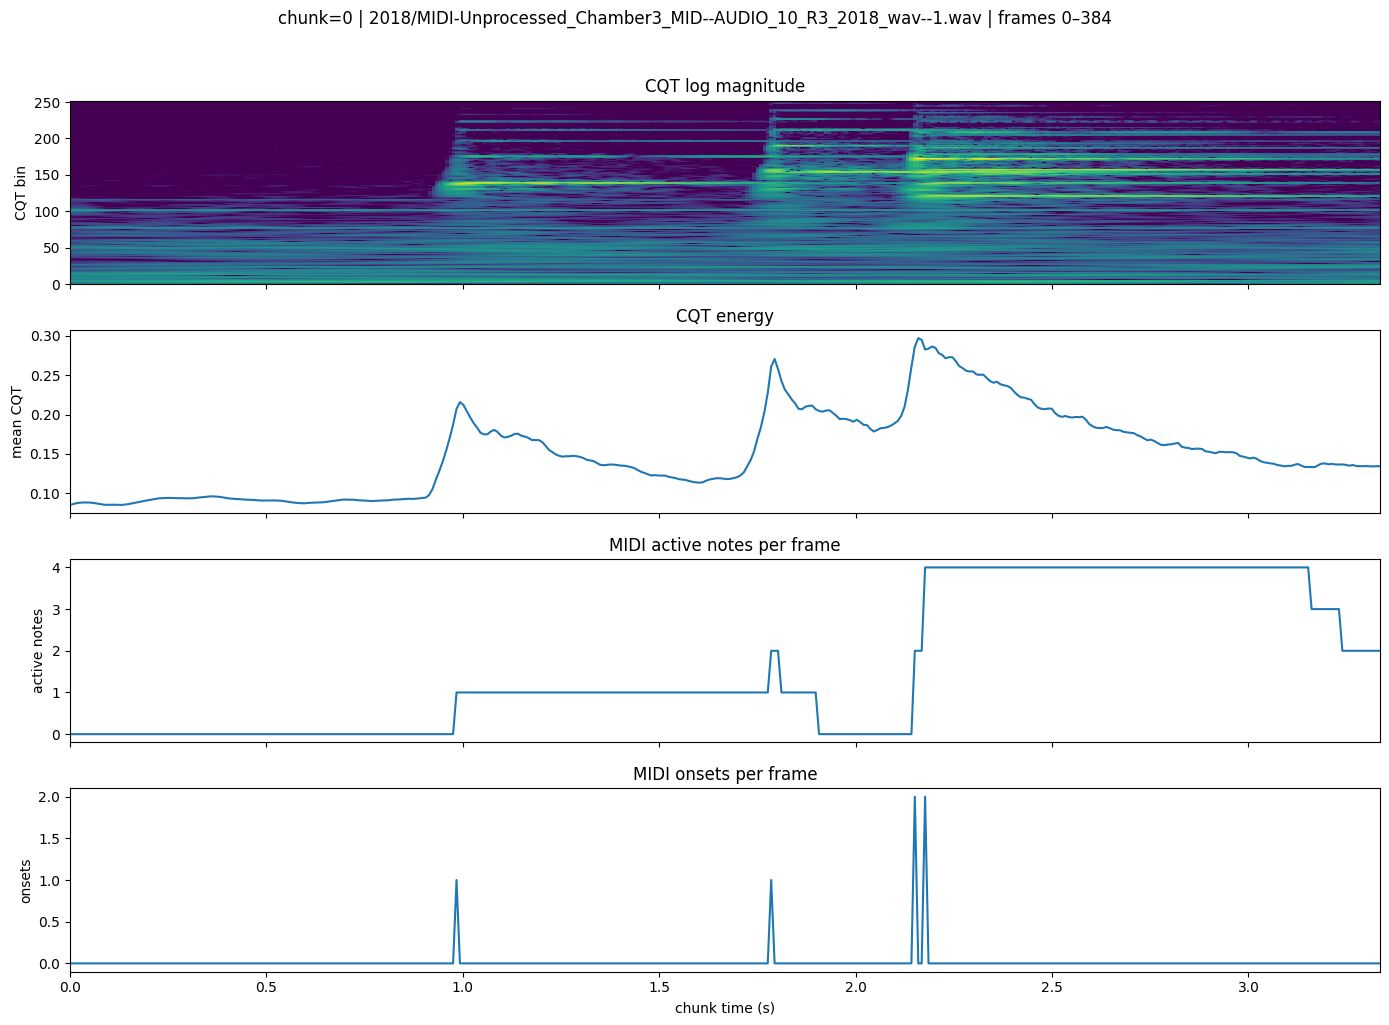

midi: 2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.midi
target mode: active_onset
X min/max: 0.0 0.7019608020782471
Y unique: [0. 1.]
active positives: 618
onset positives: 6


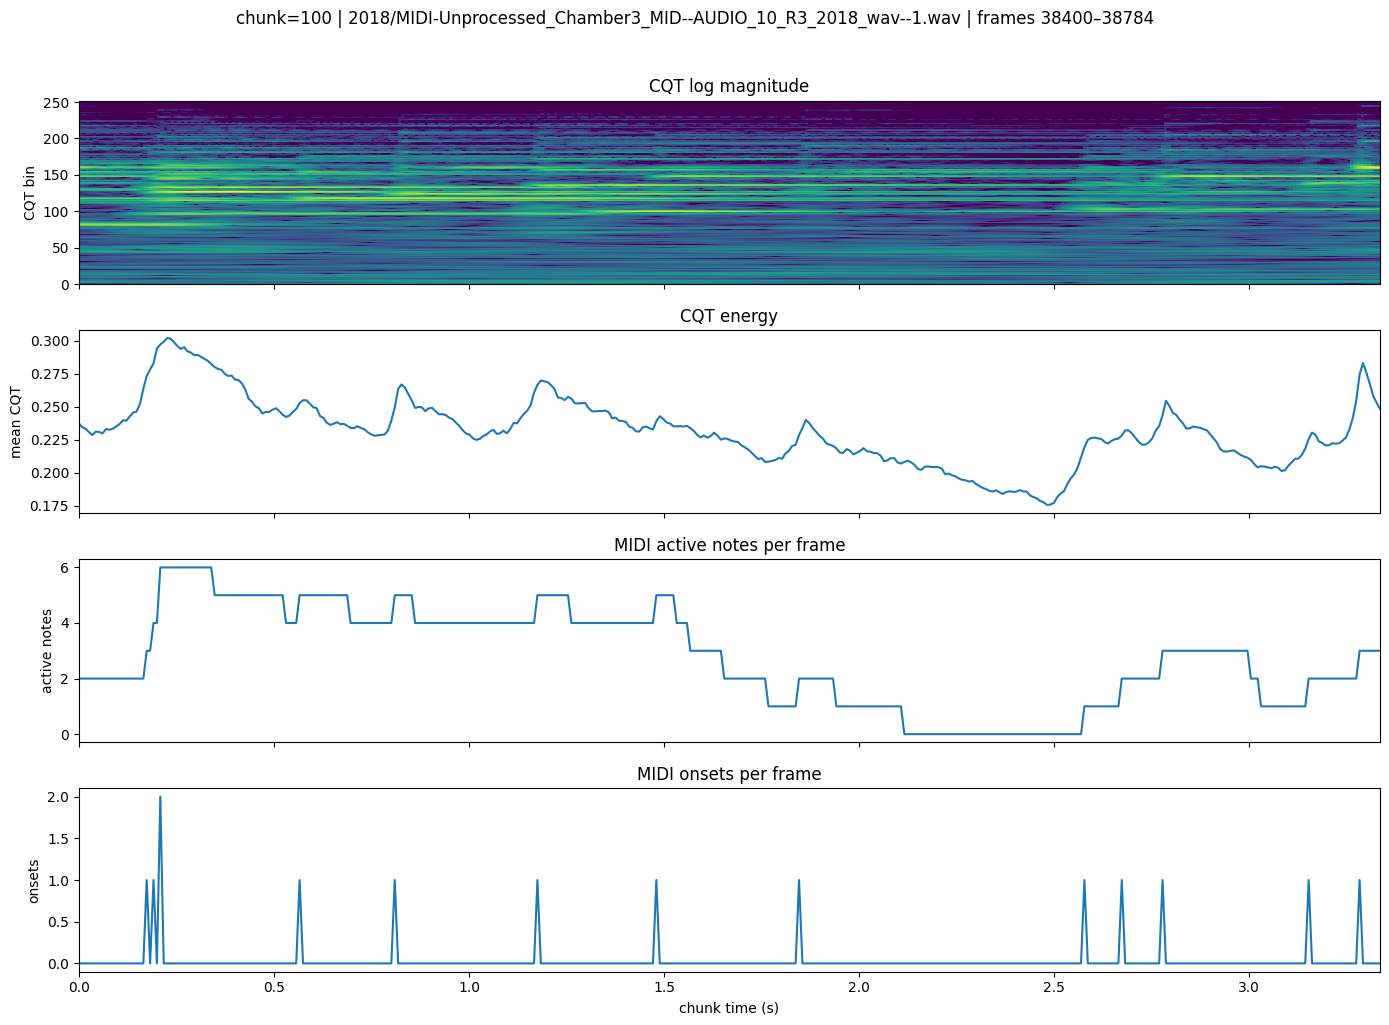

midi: 2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R3_2018_wav--1.midi
target mode: active_onset
X min/max: 0.0 0.7764706015586853
Y unique: [0. 1.]
active positives: 1059
onset positives: 14


In [29]:
plot_chunk_cqt_vs_midi_activity(OUTPUT_PATH, chunk_idx=0)
plot_chunk_cqt_vs_midi_activity(OUTPUT_PATH, chunk_idx=100)

# Dataset and DataLoader

In [30]:
def soften_binary_time_targets(
    target: np.ndarray,
    radius: int = ONSET_RADIUS,
    side_value: float = 0.5,
) -> np.ndarray:
    """
    Soft-widen binary (T, P) onset targets along time.

    Example radius=1:
        0 0 1 0 0
    becomes:
        0 0.5 1.0 0.5 0
    """
    target = target.astype(np.float32, copy=False)

    if radius <= 0:
        return target.copy()

    softened = target.copy()

    for shift in range(1, radius + 1):
        value = side_value / shift

        softened[shift:] = np.maximum(
            softened[shift:],
            target[:-shift] * value,
        )

        softened[:-shift] = np.maximum(
            softened[:-shift],
            target[shift:] * value,
        )

    return softened.astype(np.float32)
    
class MaestroChunkDataset(Dataset):
    def __init__(
        self,
        h5_path: str,
        soften_onsets: bool = True,
        onset_radius: int = 1,
        onset_side_value: float = 0.5,
    ):
        print("Loading entire dataset into system RAM... Please wait.")
        with h5py.File(str(h5_path), "r") as hf:
            self.X = hf["X"][:]
            self.Y = hf["Y"][:]
        print("Successfully loaded dataset into RAM!")

        self.soften_onsets = soften_onsets
        self.onset_radius = onset_radius
        self.onset_side_value = onset_side_value

    def __len__(self) -> int:
        return self.X.shape[0]

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        X = self.X[idx]
        Y = self.Y[idx].astype(np.float32)

        # X: uint8 0–255 -> float32 0–1
        X = torch.from_numpy(X.astype(np.float32) / 255.0).unsqueeze(0)

        # Y: uint8/binary -> float32
        if self.soften_onsets:
            Y[..., CH_ONSET] = soften_binary_time_targets(
                Y[..., CH_ONSET],
                radius=self.onset_radius,
                side_value=self.onset_side_value,
            )

        Y = torch.from_numpy(Y)

        return X, Y



def batch_label_stats(Y: torch.Tensor) -> None:
    n = Y[..., 0].numel()
    active_pos = Y[..., 0].sum().item()
    onset_pos = Y[..., 1].sum().item()

    print(f"active positives: {active_pos:.0f} / {n} = {active_pos / n:.6f}")
    print(f"onset positives : {onset_pos:.0f} / {n} = {onset_pos / n:.6f}")

In [31]:
dataset = MaestroChunkDataset(
    OUTPUT_PATH,
    soften_onsets=True,
    onset_radius=1,
    onset_side_value=0.25,
)

debug_train_dataset = MaestroChunkDataset(
    OUTPUT_PATH,
    soften_onsets=False,
)
val_dataset = MaestroChunkDataset(VAL_PATH, soften_onsets=False)

n_total = len(dataset)
n_val = int(0.1 * n_total)
n_train = n_total - n_val



print("num chunks:", len(dataset))

X, Y = dataset[0]
print("X:", X.shape)
print("Y:", Y.shape)
print("X min/max:", X.min().item(), X.max().item())
print("Y min/max:", Y.min().item(), Y.max().item())
batch_label_stats(Y)

for i in range(5):
    _, Y_i = dataset[i]
    print(
        i,
        "active:", int(Y_i[..., 0].sum().item()),
        "onset:", int(Y_i[..., 1].sum().item()),)

Loading entire dataset into system RAM... Please wait.
Successfully loaded dataset into RAM!
Loading entire dataset into system RAM... Please wait.
Successfully loaded dataset into RAM!
Loading entire dataset into system RAM... Please wait.
Successfully loaded dataset into RAM!
num chunks: 1641
X: torch.Size([1, 384, 252])
Y: torch.Size([384, 88, 2])
X min/max: 0.0 0.7019608020782471
Y min/max: 0.0 1.0
active positives: 618 / 33792 = 0.018288
onset positives : 9 / 33792 = 0.000266
0 active: 618 onset: 9
1 active: 831 onset: 22
2 active: 936 onset: 15
3 active: 995 onset: 3
4 active: 627 onset: 13


# Check onsets

In [32]:
def dataset_label_stats(dataset, max_items: int | None = None):
    active_pos = 0.0
    onset_pos = 0.0
    total = 0
    chunks_with_no_onsets = 0
    onset_per_chunk = []
    active_per_chunk = []

    n = len(dataset) if max_items is None else min(len(dataset), max_items)

    for i in tqdm(range(n), desc="label stats"):
        _, Y = dataset[i]  # (T, 88, 2)

        active_count = Y[..., 0].sum().item()
        onset_count = Y[..., 1].sum().item()
        frame_pitch_count = Y[..., 0].numel()

        active_pos += active_count
        onset_pos += onset_count
        total += frame_pitch_count
        chunks_with_no_onsets += int(onset_count == 0)
        active_per_chunk.append(active_count)
        onset_per_chunk.append(onset_count)

    active_neg = total - active_pos
    onset_neg = total - onset_pos
    active_per_chunk = np.asarray(active_per_chunk, dtype=np.float32)
    onset_per_chunk = np.asarray(onset_per_chunk, dtype=np.float32)

    print(f"active positives: {active_pos:.0f} / {total} = {active_pos / total:.8f}")
    print(f"onset positives : {onset_pos:.0f} / {total} = {onset_pos / total:.8f}")
    print(f"active pos_weight approx {active_neg / max(active_pos, 1):.2f}")
    print(f"onset  pos_weight approx {onset_neg / max(onset_pos, 1):.2f}")
    print(f"mean active labels/chunk: {active_per_chunk.mean():.2f}")
    print(f"mean onset labels/chunk : {onset_per_chunk.mean():.2f}")
    print(f"max onset labels/chunk  : {onset_per_chunk.max(initial=0):.0f}")
    print(f"chunks with zero onsets : {chunks_with_no_onsets} / {n} = {chunks_with_no_onsets / max(n, 1):.4f}")

dataset_label_stats(dataset)

label stats:   0%|          | 0/1641 [00:00<?, ?it/s]

active positives: 1505237 / 55452672 = 0.02714454
onset positives : 74818 / 55452672 = 0.00134922
active pos_weight approx 35.84
onset  pos_weight approx 740.17
mean active labels/chunk: 917.27
mean onset labels/chunk : 45.59
max onset labels/chunk  : 164
chunks with zero onsets : 29 / 1641 = 0.0177


In [33]:
loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Dataset type:", type(dataset).__name__)
print("Dataset length:", len(dataset))
print("Loader batch_size:", loader.batch_size)
print("Loader num_workers:", loader.num_workers)
print("Loader pin_memory:", loader.pin_memory)
print("Number of batches:", len(loader))


Dataset type: MaestroChunkDataset
Dataset length: 1641
Loader batch_size: 8
Loader num_workers: 2
Loader pin_memory: True
Number of batches: 206


# Model architecture

In [34]:
# Harmonic stacking
class HarmonicStacking(nn.Module):
    """
    Takes CQT input (B, 1, T, F) and stacks shifted frequency views.

    Each harmonic ratio h corresponds to a shift of:
        bins_per_octave * log2(h)

    Example ratios:
        [0.5, 1, 2, 3, 4, 5, 6, 7]
    """
    def __init__(
        self,
        bins_per_octave: int,
        harmonics=(0.5, 1, 2, 3, 4, 5, 6, 7),
        target_bins: int | None = None,
    ):
        super().__init__()
        self.bins_per_octave = bins_per_octave
        self.harmonics = harmonics
        self.target_bins = target_bins

        self.shifts = [
            int(round(bins_per_octave * math.log2(h)))
            for h in harmonics
        ]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, 1, T, F)
        assert x.ndim == 4
        B, C, T, Freq = x.shape
        assert C == 1

        stacked = []

        for shift in self.shifts:
            # For candidate pitch bin p, we want to read energy at p + shift.
            # Positive shift means harmonic is higher in frequency.
            if shift > 0:
                shifted = F.pad(x[..., shift:], (0, shift))
            elif shift < 0:
                shifted = F.pad(x[..., :shift], (-shift, 0))
            else:
                shifted = x

            stacked.append(shifted)

        # (B, H, T, F)
        x = torch.cat(stacked, dim=1)

        if self.target_bins is not None:
            x = x[..., :self.target_bins]

        return x

# Freq projector
class LocalFreqProjector(nn.Module):
    def __init__(self, n_bins=252, n_pitches=88, channels=128):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=5, padding=2, groups=channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size=1),
        )
        self.n_pitches = n_pitches

    def forward(self, h):
        # h: (B, C, T, F)
        B, C, T, Freq = h.shape

        h = h.permute(0, 2, 1, 3).reshape(B * T, C, Freq)
        h = self.proj(h)
        h = F.adaptive_avg_pool1d(h, self.n_pitches)
        h = h.reshape(B, T, C, self.n_pitches).permute(0, 2, 1, 3)

        return h


# ── CNN frontend ──────────────────────────────────────────────────────────────
 
class ConvBlock(nn.Module):
    """Conv2d → BN → GELU, no time-axis stride ever."""
    def __init__(self, in_ch: int, out_ch: int, kernel: int = 3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=kernel,
                      padding=kernel // 2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)
 
 
class CNNFrontend(nn.Module):
    """
    Maps (B, 1, T, F=N_BINS) → (B, d_model, T, 88).
 
    Strategy
    --------
    Three conv blocks progressively expand channels.
    A final adaptive pool along the frequency axis collapses F → 88.
    Time axis is never touched.
    """
    def __init__(self, d_model: int = 128):
        super().__init__()
        self.hstack = HarmonicStacking(
            bins_per_octave=BINS_PER_OCTAVE,
            harmonics=(0.5, 1, 2, 3, 4, 5, 6, 7),
            target_bins=N_BINS,
        )

        self.convs = nn.Sequential(
            ConvBlock(8, 32),
            ConvBlock(32, 64),
            ConvBlock(64, d_model),
        )
        # Learned projection: F=252 → 88 along the frequency axis
        # AdaptiveAvgPool2d(output_size=(T, 88)) would pool time too,
        # so we pool frequency only with a 1D adaptive pool.
        self.freq_proj = nn.Sequential( # This could also be a Conv1D 
            nn.Linear(N_BINS, N_PITCHES),
            nn.GELU(),
        )
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.hstack(x)       # (B, 8, T, F)
        x = self.convs(x)        # (B, C, T, F)
        x = self.freq_proj(x)    # (B, C, T, 88)
        return x
 
 
# ── positional embeddings ─────────────────────────────────────────────────────
 
class AxialPositionalEmbedding(nn.Module):
    """
    Learned additive embeddings along time and pitch axes, broadcast over
    the other axis so they can simply be summed together.
 
        time  embed: (1, T_max, 1,  C)
        pitch embed: (1, 1,     88, C)
    """
    def __init__(self, d_model: int, max_frames: int = 512):
        super().__init__()
        self.time_emb  = nn.Embedding(max_frames, d_model)
        self.pitch_emb = nn.Embedding(N_PITCHES,    d_model)
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, 88, C)
        B, T, P, C = x.shape
        t_idx = torch.arange(T, device=x.device)          # (T,)
        p_idx = torch.arange(P, device=x.device)          # (88,)
        t_emb = self.time_emb(t_idx).unsqueeze(1)         # (T, 1,  C)
        p_emb = self.pitch_emb(p_idx).unsqueeze(0)        # (1, 88, C)
        return x + t_emb + p_emb                          # broadcast over B
 
 
# ── axial attention blocks ────────────────────────────────────────────────────
 
class TimeAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int):
        super().__init__()
        self.attn = SDPASelfAttention(d_model, n_heads, dropout=0.1)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, P, C = x.shape
        h = x.permute(0, 2, 1, 3).reshape(B * P, T, C)
        h = self.attn(h)
        h = h.reshape(B, P, T, C).permute(0, 2, 1, 3)
        return self.norm(x + h)


class PitchAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int):
        super().__init__()
        self.attn = SDPASelfAttention(d_model, n_heads, dropout=0.1)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, P, C = x.shape
        h = x.reshape(B * T, P, C)
        h = self.attn(h)
        h = h.reshape(B, T, P, C)
        return self.norm(x + h)
 
 
class FeedForward(nn.Module):
    def __init__(self, d_model: int, expansion: int = 4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_model * expansion),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(d_model * expansion, d_model),
            nn.Dropout(0.1),
        )
        self.norm = nn.LayerNorm(d_model)
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.norm(x + self.net(x))
 
 
class AxialBlock(nn.Module):
    """One axial transformer block: TimeAttn → PitchAttn → FFN."""
    def __init__(self, d_model: int, n_heads: int):
        super().__init__()
        self.time_attn  = TimeAttention(d_model, n_heads)
        self.pitch_attn = PitchAttention(d_model, n_heads)
        self.ffn        = FeedForward(d_model)
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.time_attn(x)
        x = self.pitch_attn(x)
        x = self.ffn(x)
        return x

class SDPASelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.dropout = dropout

        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out = nn.Linear(d_model, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (Bseq, L, C)
        Bseq, L, C = x.shape

        qkv = self.qkv(x)
        qkv = qkv.view(Bseq, L, 3, self.n_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, Bseq, H, L, D)

        q, k, v = qkv[0], qkv[1], qkv[2]

        dropout_p = self.dropout if self.training else 0.0

        h = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=None,
            dropout_p=dropout_p,
            is_causal=False,
        )

        h = h.transpose(1, 2).contiguous().view(Bseq, L, C)
        return self.out(h)


 
# ── full model ────────────────────────────────────────────────────────────────
class PianoTranscriber(nn.Module):
    def __init__(self, n_bins=252, n_pitches=88, d_model=128, n_layers=1, n_heads=4):
        super().__init__()

        self.hstack = HarmonicStacking(
            bins_per_octave=BINS_PER_OCTAVE,
            harmonics=(0.5, 1, 2, 3, 4, 5, 6, 7),
            target_bins=n_bins,
        )

        self.trunk = nn.Sequential(
            ConvBlock(8, 32, kernel=5),
            ConvBlock(32, 64, kernel=3),
            ConvBlock(64, d_model, kernel=3),
        )

        self.freq_proj = nn.Linear(n_bins, n_pitches)

        self.note_conv = nn.Sequential(
            ConvBlock(d_model, d_model, kernel=3),
            nn.Conv2d(d_model, 1, kernel_size=1),
        )

        self.onset_conv = nn.Sequential(
            ConvBlock(d_model + 1, d_model, kernel=3),
            nn.Conv2d(d_model, 1, kernel_size=1),
        )

        self.pos = AxialPositionalEmbedding(d_model, max_frames=CHUNK_FRAMES)
        self.blocks  = nn.ModuleList([
                AxialBlock(d_model, n_heads) for _ in range(n_layers)
            ])
     
        self.head = nn.Linear(d_model, N_TARGET_CHANNELS)        

    def forward(self, x):
        if x.ndim == 3:
            x = x.unsqueeze(1)
    
        x = self.hstack(x)             # (B, 8,       T, F)   channels-first
        h = self.trunk(x)              # (B, C,       T, F)   channels-first
        h = self.freq_proj(h)          # (B, C,       T, 88)  channels-first
    
        # ── into attention-land ───────────────────────────────────────────────
        h = h.permute(0, 2, 3, 1)     # (B, T, 88,   C)      channels-last ✓
        h = self.pos(h)                # (B, T, 88,   C)
        for block in self.blocks:
            h = block(h)               # (B, T, 88,   C)
        h = h.permute(0, 3, 1, 2)     # (B, C,  T,  88)      channels-first ✓
        # ─────────────────────────────────────────────────────────────────────
    
        note_logit  = self.note_conv(h)                    # (B, 1,   T, 88)
        onset_in    = torch.cat([h, note_logit], dim=1)    # (B, C+1, T, 88)
        onset_logit = self.onset_conv(onset_in)            # (B, 1,   T, 88)
    
        logits = torch.cat([note_logit, onset_logit], dim=1)  # (B, 2, T, 88)
        logits = logits.permute(0, 2, 3, 1)                   # (B, T, 88, 2)
        return logits
def amt_loss(
    logits: torch.Tensor,
    targets: torch.Tensor,
    active_pos_weight: float = 35.0,
    onset_pos_weight: float = 100.0,
    onset_loss_weight: float = 1.0,
    sustain_onset_neg_weight: float = 5.0,
) -> tuple[torch.Tensor, dict]:

    active_logits = logits[..., 0]
    onset_logits  = logits[..., 1]

    active_target = targets[..., 0]
    onset_target  = targets[..., 1]

    active_pw = torch.tensor(
        active_pos_weight,
        device=logits.device,
        dtype=logits.dtype,
    )

    loss_active = F.binary_cross_entropy_with_logits(
        active_logits,
        active_target,
        pos_weight=active_pw,
    )

    # Per-cell onset BCE so we can weight specific regions.
    onset_bce = F.binary_cross_entropy_with_logits(
        onset_logits,
        onset_target,
        reduction="none",
    )

    onset_weights = torch.ones_like(onset_bce)

    # Positive onsets still matter more.
    onset_weights = torch.where(
        onset_target > 0.5,
        torch.full_like(onset_weights, onset_pos_weight),
        onset_weights,
    )

    # Previous active frame.
    prev_active = torch.zeros_like(active_target)
    prev_active[:, 1:, :] = active_target[:, :-1, :]

    # Regions where note is already sustaining, not starting.
    sustain_no_onset = (
        (active_target > 0.5)
        & (prev_active > 0.5)
        & (onset_target < 0.5)
    )

    # Penalize false onsets during sustain extra.
    onset_weights = torch.where(
        sustain_no_onset,
        onset_weights * sustain_onset_neg_weight,
        onset_weights,
    )

    loss_onset = (onset_bce * onset_weights).mean()

    loss = loss_active + onset_loss_weight * loss_onset

    return loss, {
        "active": loss_active.detach().item(),
        "onset": loss_onset.detach().item(),
        "total": loss.detach().item(),
    }
# ── parameter count utility ───────────────────────────────────────────────────
 
def count_params(model: nn.Module) -> str:
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return f"total={total/1e6:.2f}M  trainable={trainable/1e6:.2f}M"

# Model checks

In [35]:
"""
test_model = PianoTranscriber(
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    max_frames=CHUNK_FRAMES,
)

test_x = torch.randn(BATCH_SIZE, 1, CHUNK_FRAMES, N_BINS)
test_target = torch.zeros(BATCH_SIZE, CHUNK_FRAMES, N_PITCHES, N_TARGET_CHANNELS)

print(f"Params : {count_params(test_model)}")
print(f"Input  : {tuple(test_x.shape)}")

with torch.no_grad():
    test_logits = test_model(test_x)

print(f"Output : {tuple(test_logits.shape)}")
loss, parts = amt_loss(test_logits, test_target)
print(f"Loss   : {parts}")
"""

'\ntest_model = PianoTranscriber(\n    d_model=D_MODEL,\n    n_heads=N_HEADS,\n    n_layers=N_LAYERS,\n    max_frames=CHUNK_FRAMES,\n)\n\ntest_x = torch.randn(BATCH_SIZE, 1, CHUNK_FRAMES, N_BINS)\ntest_target = torch.zeros(BATCH_SIZE, CHUNK_FRAMES, N_PITCHES, N_TARGET_CHANNELS)\n\nprint(f"Params : {count_params(test_model)}")\nprint(f"Input  : {tuple(test_x.shape)}")\n\nwith torch.no_grad():\n    test_logits = test_model(test_x)\n\nprint(f"Output : {tuple(test_logits.shape)}")\nloss, parts = amt_loss(test_logits, test_target)\nprint(f"Loss   : {parts}")\n'

In [36]:
model = PianoTranscriber().to(DEVICE)



if DEVICE == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    
    X, Y = next(iter(loader))
    X = X.to(DEVICE)
    
    logits = model(X)
    
    print("logits shape:", logits.shape)
    print("allocated GB:", torch.cuda.memory_allocated() / 1e9)
    print("reserved GB:", torch.cuda.memory_reserved() / 1e9)
    print("peak GB:", torch.cuda.max_memory_allocated() / 1e9)

summary(
    model,
    input_size=(BATCH_SIZE, 1, CHUNK_FRAMES, N_BINS),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=6,
)

logits shape: torch.Size([8, 384, 88, 2])
allocated GB: 6.49537024
reserved GB: 6.635388928
peak GB: 6.500551168


Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Trainable
PianoTranscriber                              [8, 1, 384, 252]          [8, 384, 88, 2]           258                       True
├─HarmonicStacking: 1-1                       [8, 1, 384, 252]          [8, 8, 384, 252]          --                        --
├─Sequential: 1-2                             [8, 8, 384, 252]          [8, 128, 384, 252]        --                        True
│    └─ConvBlock: 2-1                         [8, 8, 384, 252]          [8, 32, 384, 252]         --                        True
│    │    └─Sequential: 3-1                   [8, 8, 384, 252]          [8, 32, 384, 252]         --                        True
│    │    │    └─Conv2d: 4-1                  [8, 8, 384, 252]          [8, 32, 384, 252]         6,400                     True
│    │    │    └─BatchNorm2d: 4-2             [8, 32, 384, 252]         [8, 32, 384, 252]     

## Metrics

In [37]:
def peak_pick_onsets_np(
    pred_onset,
    threshold=0.5,
    pre_max=1,
    post_max=1,
    min_gap=0,
):
    """
    pred_onset: probabilities, shape (T, 88)

    Returns bool array of same shape.
    Keeps only local maxima above threshold, independently per pitch.
    """
    T, P = pred_onset.shape
    picked = np.zeros((T, P), dtype=bool)

    for p in range(P):
        x = pred_onset[:, p]

        candidates = x > threshold

        for t in np.where(candidates)[0]:
            left = max(0, t - pre_max)
            right = min(T, t + post_max + 1)

            # local max check
            if x[t] < x[left:right].max():
                continue

            picked[t, p] = True

        if min_gap > 0:
            ts = np.where(picked[:, p])[0]
            keep = []
            last = -10**9

            for t in ts:
                if t - last >= min_gap:
                    keep.append(t)
                    last = t

            picked[:, p] = False
            picked[keep, p] = True

    return picked

def onset_tolerance_metrics_peak_picked(
    pred_onset,
    true_onset,
    threshold=0.5,
    frame_tolerance=1,
    pre_max=1,
    post_max=1,
    min_gap=0,
):
    """
    pred_onset: probabilities, shape (T, 88)
    true_onset: 0/1 labels, shape (T, 88)
    """
    pred_bin = peak_pick_onsets_np(
        pred_onset,
        threshold=threshold,
        pre_max=pre_max,
        post_max=post_max,
        min_gap=min_gap,
    )

    pred_points = np.argwhere(pred_bin)
    true_points = np.argwhere(true_onset > 0.5)

    matched_true = set()
    tp = 0

    for pred_t, pred_p in pred_points:
        match = None

        for j, (true_t, true_p) in enumerate(true_points):
            if j in matched_true:
                continue

            if pred_p == true_p and abs(pred_t - true_t) <= frame_tolerance:
                match = j
                break

        if match is not None:
            matched_true.add(match)
            tp += 1

    fp = len(pred_points) - tp
    fn = len(true_points) - len(matched_true)

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)

    return {
        "threshold": threshold,
        "frame_tolerance": frame_tolerance,
        "pre_max": pre_max,
        "post_max": post_max,
        "min_gap": min_gap,
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
    }
def binary_metrics(pred, target, threshold: float, eps: float = 1e-8):
    """
    pred:   numpy array of probabilities, shape (T, 88)
    target: numpy array of 0/1 labels, shape (T, 88)
    """
    pred_bin = pred > threshold
    target_bin = target > 0.5

    tp = (pred_bin & target_bin).sum()
    fp = (pred_bin & ~target_bin).sum()
    fn = (~pred_bin & target_bin).sum()

    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)

    return {
        "threshold": threshold,
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
    }


def onset_tolerance_metrics(pred_onset, true_onset, threshold=0.5, frame_tolerance=1):
    """
    pred_onset: probabilities, shape (T, 88)
    true_onset: 0/1 labels, shape (T, 88)

    Counts a predicted onset as correct if it matches the same pitch
    within +/- frame_tolerance frames.
    """
    pred_points = np.argwhere(pred_onset > threshold)   # [t, pitch]
    true_points = np.argwhere(true_onset > 0.5)         # [t, pitch]

    matched_true = set()
    tp = 0

    for pred_t, pred_p in pred_points:
        match = None

        for j, (true_t, true_p) in enumerate(true_points):
            if j in matched_true:
                continue

            same_pitch = pred_p == true_p
            close_time = abs(pred_t - true_t) <= frame_tolerance

            if same_pitch and close_time:
                match = j
                break

        if match is not None:
            matched_true.add(match)
            tp += 1

    fp = len(pred_points) - tp
    fn = len(true_points) - len(matched_true)

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)

    return {
        "threshold": threshold,
        "frame_tolerance": frame_tolerance,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def evaluate_one_item_thresholds(
    model,
    dataset,
    idx=0,
    device=DEVICE,
    thresholds=(0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.93, 0.95, 0.97),
    onset_frame_tolerance=1,
):
    model.eval()

    X, Y = dataset[idx]          # X: (1, T, 252), Y: (T, 88, 2)
    X_batch = X.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(X_batch)
        probs = torch.sigmoid(logits)[0].cpu().numpy()

    Y = Y.cpu().numpy()

    pred_active = probs[:, :, 0]
    pred_onset = probs[:, :, 1]

    true_active = Y[:, :, 0]
    true_onset = Y[:, :, 1]

    print("Raw probability stats")
    print(f"active: mean={pred_active.mean():.4f}, max={pred_active.max():.4f}")
    print(f"onset : mean={pred_onset.mean():.4f}, max={pred_onset.max():.4f}")
    print()

    print("ACTIVE metrics")
    for th in thresholds:
        print(binary_metrics(pred_active, true_active, th))

    print()
    print("ONSET exact-cell metrics")
    for th in thresholds:
        print(binary_metrics(pred_onset, true_onset, th))

    print()
    print(f"ONSET tolerance metrics, +/- {onset_frame_tolerance} frame")
    for th in thresholds:
        print(onset_tolerance_metrics(
            pred_onset,
            true_onset,
            threshold=th,
            frame_tolerance=onset_frame_tolerance,
        ))

    return {
        "pred_active": pred_active,
        "pred_onset": pred_onset,
        "true_active": true_active,
        "true_onset": true_onset,
    }



@torch.no_grad()
def evaluate_dataset_compact(
    model,
    dataset,
    device,
    max_items=50,
    active_thresholds=(0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.93, 0.95, 0.97),
    onset_thresholds=(0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.93, 0.95, 0.97),
    onset_frame_tolerance=3,
):
    model.eval()

    n = min(max_items, len(dataset))

    results = {
        "active": {th: {"tp": 0, "fp": 0, "fn": 0} for th in active_thresholds},
        "onset": {th: {"tp": 0, "fp": 0, "fn": 0} for th in onset_thresholds},
        "onset_peak": {th: {"tp": 0, "fp": 0, "fn": 0} for th in onset_thresholds},
    }

    for idx in range(n):
        X, Y = dataset[idx]
        X = X.unsqueeze(0).to(device)

        logits = model(X)
        probs = torch.sigmoid(logits)[0].cpu().numpy()
        Y = Y.cpu().numpy()

        pred_active = probs[:, :, 0]
        pred_onset = probs[:, :, 1]

        true_active = Y[:, :, 0]
        true_onset = Y[:, :, 1]

        for th in active_thresholds:
            m = binary_metrics(pred_active, true_active, th)
            results["active"][th]["tp"] += m["tp"]
            results["active"][th]["fp"] += m["fp"]
            results["active"][th]["fn"] += m["fn"]

        for th in onset_thresholds:
            m_raw = onset_tolerance_metrics(
                pred_onset,
                true_onset,
                threshold=th,
                frame_tolerance=onset_frame_tolerance,
            )
        
            m_peak = onset_tolerance_metrics_peak_picked(
                pred_onset,
                true_onset,
                threshold=th,
                frame_tolerance=onset_frame_tolerance,
                pre_max=1,
                post_max=1,
                min_gap=2,
            )
        
            for k in ("tp", "fp", "fn"):
                results["onset"][th][k] += m_raw[k]
                results["onset_peak"][th][k] += m_peak[k]

    def finalize(counts):
        tp = counts["tp"]
        fp = counts["fp"]
        fn = counts["fn"]

        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = 2 * precision * recall / max(precision + recall, 1e-8)

        return {
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        }

    print("\nACTIVE averaged metrics")
    for th in active_thresholds:
        print(th, finalize(results["active"][th]))

    print("\nONSET averaged tolerance metrics")
    for th in onset_thresholds:
        print(th, finalize(results["onset"][th]))

    print("\nONSET averaged peak tolerance metrics")
    for th in onset_thresholds:
        print(th, finalize(results["onset_peak"][th]))

    return results

# Training

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = PianoTranscriber()

#if torch.cuda.device_count() > 1:
#    print(f"Using {torch.cuda.device_count()} GPUs")
#    model = torch.nn.DataParallel(model)

model = model.to(device)

print("device:", device)
print("model device:", next(model.parameters()).device)
print("num train batches:", len(loader))

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

thresholds = (0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.93, 0.95, 0.97)

for epoch in range(NUM_EPOCHS):
    model.train()

    running_total = 0.0
    running_active = 0.0
    running_onset = 0.0

    pbar = tqdm(
        loader,
        desc=f"epoch {epoch + 1:02d}/{NUM_EPOCHS}",
    )

    for X, Y in pbar:
        X = X.to(device, non_blocking=True)
        Y = Y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(X)

            loss, parts = amt_loss(
                logits,
                Y,
                active_pos_weight=active_pos_weight,
                onset_pos_weight=onset_pos_weight,
                onset_loss_weight=onset_loss_weight,
                sustain_onset_neg_weight=sustain_onset_neg_weight
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        scaler.step(optimizer)
        scaler.update()

        running_total += parts["total"]
        running_active += parts["active"]
        running_onset += parts["onset"]

        pbar.set_postfix({
            "loss": f"{parts['total']:.4f}",
            "active": f"{parts['active']:.4f}",
            "onset": f"{parts['onset']:.4f}",
        })

    n_batches = len(loader)

    avg_total = running_total / n_batches
    avg_active = running_active / n_batches
    avg_onset = running_onset / n_batches

    print(
        f"\nEpoch {epoch + 1} train avg | "
        f"loss={avg_total:.4f} | "
        f"active={avg_active:.4f} | "
        f"onset={avg_onset:.4f}"
    )

    raw_model = model.module if isinstance(model, torch.nn.DataParallel) else model
    
    print("\nDEBUG TRAIN SAMPLE — hard labels")
    evaluate_dataset_compact(
        raw_model,
        debug_train_dataset,
        device=device,
        max_items=50,
        onset_frame_tolerance=3,
    )
    print("\nVALIDATION SAMPLE — hard labels")
    evaluate_dataset_compact(
        raw_model,
        val_dataset,
        device=device,
        max_items=50,
        onset_frame_tolerance=3,
    )

    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": raw_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "config": {
            "d_model": D_MODEL,
            "n_heads": N_HEADS,
            "n_layers": N_LAYERS,
            "n_heads": 4,
            "max_frames": CHUNK_FRAMES,
            "chunk_frames": CHUNK_FRAMES,
            "active_pos_weight": active_pos_weight,
            "onset_pos_weight": onset_pos_weight,
            "onset_loss_weight": onset_loss_weight,
            "sustain_onset_neg_weight":sustain_onset_neg_weight,
            "soften_onsets": True,
            "onset_radius": 1,
            "onset_side_value": 0.5,
        },
    }, f"checkpoint_epoch_{epoch + 1}.pt")



device: cuda
model device: cuda:0
num train batches: 206


epoch 01/30:   0%|          | 0/206 [00:00<?, ?it/s]


Epoch 1 train avg | loss=0.8074 | active=0.5093 | onset=0.2981

DEBUG TRAIN SAMPLE — hard labels

ACTIVE averaged metrics
0.5 {'tp': 41339, 'fp': 107690, 'fn': 5873, 'precision': 0.2773889645639439, 'recall': 0.8756036600864187, 'f1': 0.42130849312834723}
0.6 {'tp': 38358, 'fp': 80577, 'fn': 8854, 'precision': 0.32251229663261444, 'recall': 0.8124629331525883, 'f1': 0.4617356918873047}
0.7 {'tp': 34559, 'fp': 56809, 'fn': 12653, 'precision': 0.378239646265651, 'recall': 0.7319961026857579, 'f1': 0.49875883965940254}
0.8 {'tp': 29161, 'fp': 35449, 'fn': 18051, 'precision': 0.4513388020430274, 'recall': 0.6176607642124884, 'f1': 0.521561052386829}
0.85 {'tp': 24899, 'fp': 24671, 'fn': 22313, 'precision': 0.5022997780915877, 'recall': 0.5273871049733119, 'f1': 0.5145378272819326}
0.9 {'tp': 19136, 'fp': 14016, 'fn': 28076, 'precision': 0.5772200772200772, 'recall': 0.40532068118275016, 'f1': 0.47623313921656457}
0.93 {'tp': 14067, 'fp': 7754, 'fn': 33145, 'precision': 0.6446542321616792,

epoch 02/30:   0%|          | 0/206 [00:00<?, ?it/s]


Epoch 2 train avg | loss=0.3961 | active=0.3052 | onset=0.0908

DEBUG TRAIN SAMPLE — hard labels

ACTIVE averaged metrics
0.5 {'tp': 41854, 'fp': 80797, 'fn': 5358, 'precision': 0.34124466983554963, 'recall': 0.886511903753283, 'f1': 0.49279713651589807}
0.6 {'tp': 39435, 'fp': 63028, 'fn': 7777, 'precision': 0.3848706362296634, 'recall': 0.8352749301025163, 'f1': 0.5269417070319025}
0.7 {'tp': 35990, 'fp': 47154, 'fn': 11222, 'precision': 0.43286346579428464, 'recall': 0.7623061933406761, 'f1': 0.5521801834974992}
0.8 {'tp': 30966, 'fp': 31174, 'fn': 16246, 'precision': 0.49832635983263596, 'recall': 0.6558925696856731, 'f1': 0.5663545248372228}
0.85 {'tp': 27280, 'fp': 22892, 'fn': 19932, 'precision': 0.5437295702782429, 'recall': 0.5778191985088537, 'f1': 0.5602563049371561}
0.9 {'tp': 21519, 'fp': 13837, 'fn': 25693, 'precision': 0.6086378549609684, 'recall': 0.4557951368296196, 'f1': 0.5212430965991668}
0.93 {'tp': 16349, 'fp': 7973, 'fn': 30863, 'precision': 0.6721897870240934, 

...


Epoch 28 train avg | loss=0.1380 | active=0.1148 | onset=0.0231

DEBUG TRAIN SAMPLE — hard labels

ACTIVE averaged metrics
0.5 {'tp': 46741, 'fp': 41230, 'fn': 471, 'precision': 0.5313228222937104, 'recall': 0.9900237227823435, 'f1': 0.6915218629561409}
0.6 {'tp': 46451, 'fp': 35771, 'fn': 761, 'precision': 0.564946121476004, 'recall': 0.9838812166398373, 'f1': 0.7177557674181436}
0.7 {'tp': 45943, 'fp': 29970, 'fn': 1269, 'precision': 0.605205959453585, 'recall': 0.9731212403626197, 'f1': 0.746282233502538}
0.8 {'tp': 44780, 'fp': 23120, 'fn': 2432, 'precision': 0.659499263622975, 'recall': 0.9484876726256036, 'f1': 0.7780248801167559}
0.85 {'tp': 43498, 'fp': 19070, 'fn': 3714, 'precision': 0.6952116097685718, 'recall': 0.9213335592645937, 'f1': 0.7924576425578429}
0.9 {'tp': 40983, 'fp': 14318, 'fn': 6229, 'precision': 0.7410896728811414, 'recall': 0.8680632042701009, 'f1': 0.7995668842000526}
0.93 {'tp': 38004, 'fp': 10639, 'fn': 9208, 'precision': 0.7812840490923668, 'recall': 0.

epoch 29/30:   0%|          | 0/206 [00:00<?, ?it/s]


Epoch 29 train avg | loss=0.1353 | active=0.1124 | onset=0.0229

DEBUG TRAIN SAMPLE — hard labels

ACTIVE averaged metrics
0.5 {'tp': 46794, 'fp': 39774, 'fn': 418, 'precision': 0.5405461602439701, 'recall': 0.9911463187325257, 'f1': 0.6995664523845118}
0.6 {'tp': 46521, 'fp': 34706, 'fn': 691, 'precision': 0.5727282800054169, 'recall': 0.9853638905363044, 'f1': 0.7244061383224721}
0.7 {'tp': 45965, 'fp': 29538, 'fn': 1247, 'precision': 0.6087837569368104, 'recall': 0.9735872235872236, 'f1': 0.7491341726765268}
0.8 {'tp': 44854, 'fp': 23286, 'fn': 2358, 'precision': 0.6582624009392427, 'recall': 0.950055070744726, 'f1': 0.7776891601359316}
0.85 {'tp': 43588, 'fp': 19489, 'fn': 3624, 'precision': 0.6910284255750908, 'recall': 0.9232398542743371, 'f1': 0.7904324093971293}
0.9 {'tp': 41367, 'fp': 14839, 'fn': 5845, 'precision': 0.7359890403159804, 'recall': 0.8761967296450055, 'f1': 0.7999961322013576}
0.93 {'tp': 38790, 'fp': 11242, 'fn': 8422, 'precision': 0.7753038055644388, 'recall':

epoch 30/30:   0%|          | 0/206 [00:00<?, ?it/s]


Epoch 30 train avg | loss=0.1328 | active=0.1104 | onset=0.0224

DEBUG TRAIN SAMPLE — hard labels

ACTIVE averaged metrics
0.5 {'tp': 46743, 'fp': 40064, 'fn': 469, 'precision': 0.5384703998525464, 'recall': 0.9900660848936711, 'f1': 0.6975578089673852}
0.6 {'tp': 46489, 'fp': 35337, 'fn': 723, 'precision': 0.5681445995160462, 'recall': 0.9846860967550622, 'f1': 0.720547435639114}
0.7 {'tp': 46063, 'fp': 30348, 'fn': 1149, 'precision': 0.6028320529766656, 'recall': 0.9756629670422774, 'f1': 0.7452173139302557}
0.8 {'tp': 45221, 'fp': 24370, 'fn': 1991, 'precision': 0.6498110387837508, 'recall': 0.9578285181733458, 'f1': 0.7743123036223385}
0.85 {'tp': 44386, 'fp': 20749, 'fn': 2826, 'precision': 0.6814462270668611, 'recall': 0.9401423366940609, 'f1': 0.7901590607670876}
0.9 {'tp': 42687, 'fp': 16250, 'fn': 4525, 'precision': 0.7242818602914977, 'recall': 0.9041557231212404, 'f1': 0.8042845434248085}
0.93 {'tp': 40611, 'fp': 12744, 'fn': 6601, 'precision': 0.7611470340174304, 'recall':

# Visualize

In [39]:
def active_fp_distance_stats(
    pred_active,
    true_active,
    threshold=0.8,
    max_print_dist=24,
):
    pred = pred_active > threshold
    true = true_active > 0.5

    distances = []

    T, P = pred.shape

    for t in range(T):
        true_ps = np.where(true[t])[0]
        fp_ps = np.where(pred[t] & ~true[t])[0]

        if len(true_ps) == 0:
            continue

        for p in fp_ps:
            distances.append(np.min(np.abs(true_ps - p)))

    distances = np.array(distances)

    if len(distances) == 0:
        print("No active false positives near frames with true active notes.")
        return distances

    print("Active FP distance to nearest true active pitch")
    print("count:", len(distances))
    print("median:", np.median(distances))
    print("mean:", distances.mean())

    for d in range(1, max_print_dist + 1):
        pct = np.mean(distances == d) * 100
        if pct > 0:
            print(f"distance {d:2d}: {pct:5.2f}%")

    return distances
    
def plot_prediction_vs_target(
    model: nn.Module,
    dataset: Dataset,
    idx: int = 0,
    device: str = DEVICE,
    active_thresh: float = 0.8,
    onset_thresh: float = 0.5,
    use_peak_onsets: bool = True,
    onset_pre_max: int = 2,
    onset_post_max: int = 2,
    onset_min_gap: int = 4,
) -> None:
    model.eval()

    X, Y = dataset[idx]
    X_batch = X.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(X_batch)
        probs = torch.sigmoid(logits)[0].cpu()

    Y = Y.cpu()

    cqt = X[0].cpu().numpy()  # (T, 252)

    pred_active = probs[:, :, 0].numpy()
    pred_onset = probs[:, :, 1].numpy()
    true_active = Y[:, :, 0].numpy()
    true_onset = Y[:, :, 1].numpy()

    pred_active_bin = pred_active > active_thresh
    true_active_bin = true_active > 0.5

    active_tp = pred_active_bin & true_active_bin
    active_fp = pred_active_bin & ~true_active_bin
    active_fn = ~pred_active_bin & true_active_bin

    if use_peak_onsets:
        pred_onset_bin = peak_pick_onsets_np(
            pred_onset,
            threshold=onset_thresh,
            pre_max=onset_pre_max,
            post_max=onset_post_max,
            min_gap=onset_min_gap,
        )
    else:
        pred_onset_bin = pred_onset > onset_thresh

    true_onset_bin = true_onset > 0.5

    fig, axes = plt.subplots(8, 1, figsize=(14, 18), sharex=True)

    axes[0].imshow(cqt.T, aspect="auto", origin="lower", interpolation="nearest")
    axes[0].set_title("Input CQT")

    axes[1].imshow(true_active.T, aspect="auto", origin="lower", interpolation="nearest")
    axes[1].set_title("True active")

    axes[2].imshow(pred_active.T, aspect="auto", origin="lower", interpolation="nearest", vmin=0, vmax=1)
    axes[2].set_title("Predicted active probability")

    axes[3].imshow(active_fp.T, aspect="auto", origin="lower", interpolation="nearest")
    axes[3].set_title(f"Active false positives > {active_thresh}")

    axes[4].imshow(active_fn.T, aspect="auto", origin="lower", interpolation="nearest")
    axes[4].set_title(f"Active false negatives @ {active_thresh}")

    axes[5].imshow(true_onset.T, aspect="auto", origin="lower", interpolation="nearest")
    axes[5].set_title("True onset")

    axes[6].imshow(pred_onset.T, aspect="auto", origin="lower", interpolation="nearest", vmin=0, vmax=1)
    axes[6].set_title("Predicted onset probability")

    axes[7].imshow(pred_onset_bin.T, aspect="auto", origin="lower", interpolation="nearest")
    axes[7].set_title(f"Predicted onset events after peak-picking > {onset_thresh}")

    axes[7].set_xlabel("Frame")

    for ax in axes:
        ax.set_ylabel("Pitch index")

    plt.tight_layout()
    plt.show()

    print("Pred active > threshold:", int(pred_active_bin.sum()))
    print("True active positives:", int(true_active_bin.sum()))
    print("Active TP:", int(active_tp.sum()))
    print("Active FP:", int(active_fp.sum()))
    print("Active FN:", int(active_fn.sum()))
    print()
    print("Pred onset events:", int(pred_onset_bin.sum()))
    print("True onset positives:", int(true_onset_bin.sum()))

    dists = active_fp_distance_stats(
        pred_active,
        true_active,
        threshold=active_thresh,
    )

    return {
        "pred_active": pred_active,
        "pred_onset": pred_onset,
        "true_active": true_active,
        "true_onset": true_onset,
        "pred_active_bin": pred_active_bin,
        "pred_onset_bin": pred_onset_bin,
        "active_fp": active_fp,
        "active_fn": active_fn,
        "fp_distances": dists,
    }

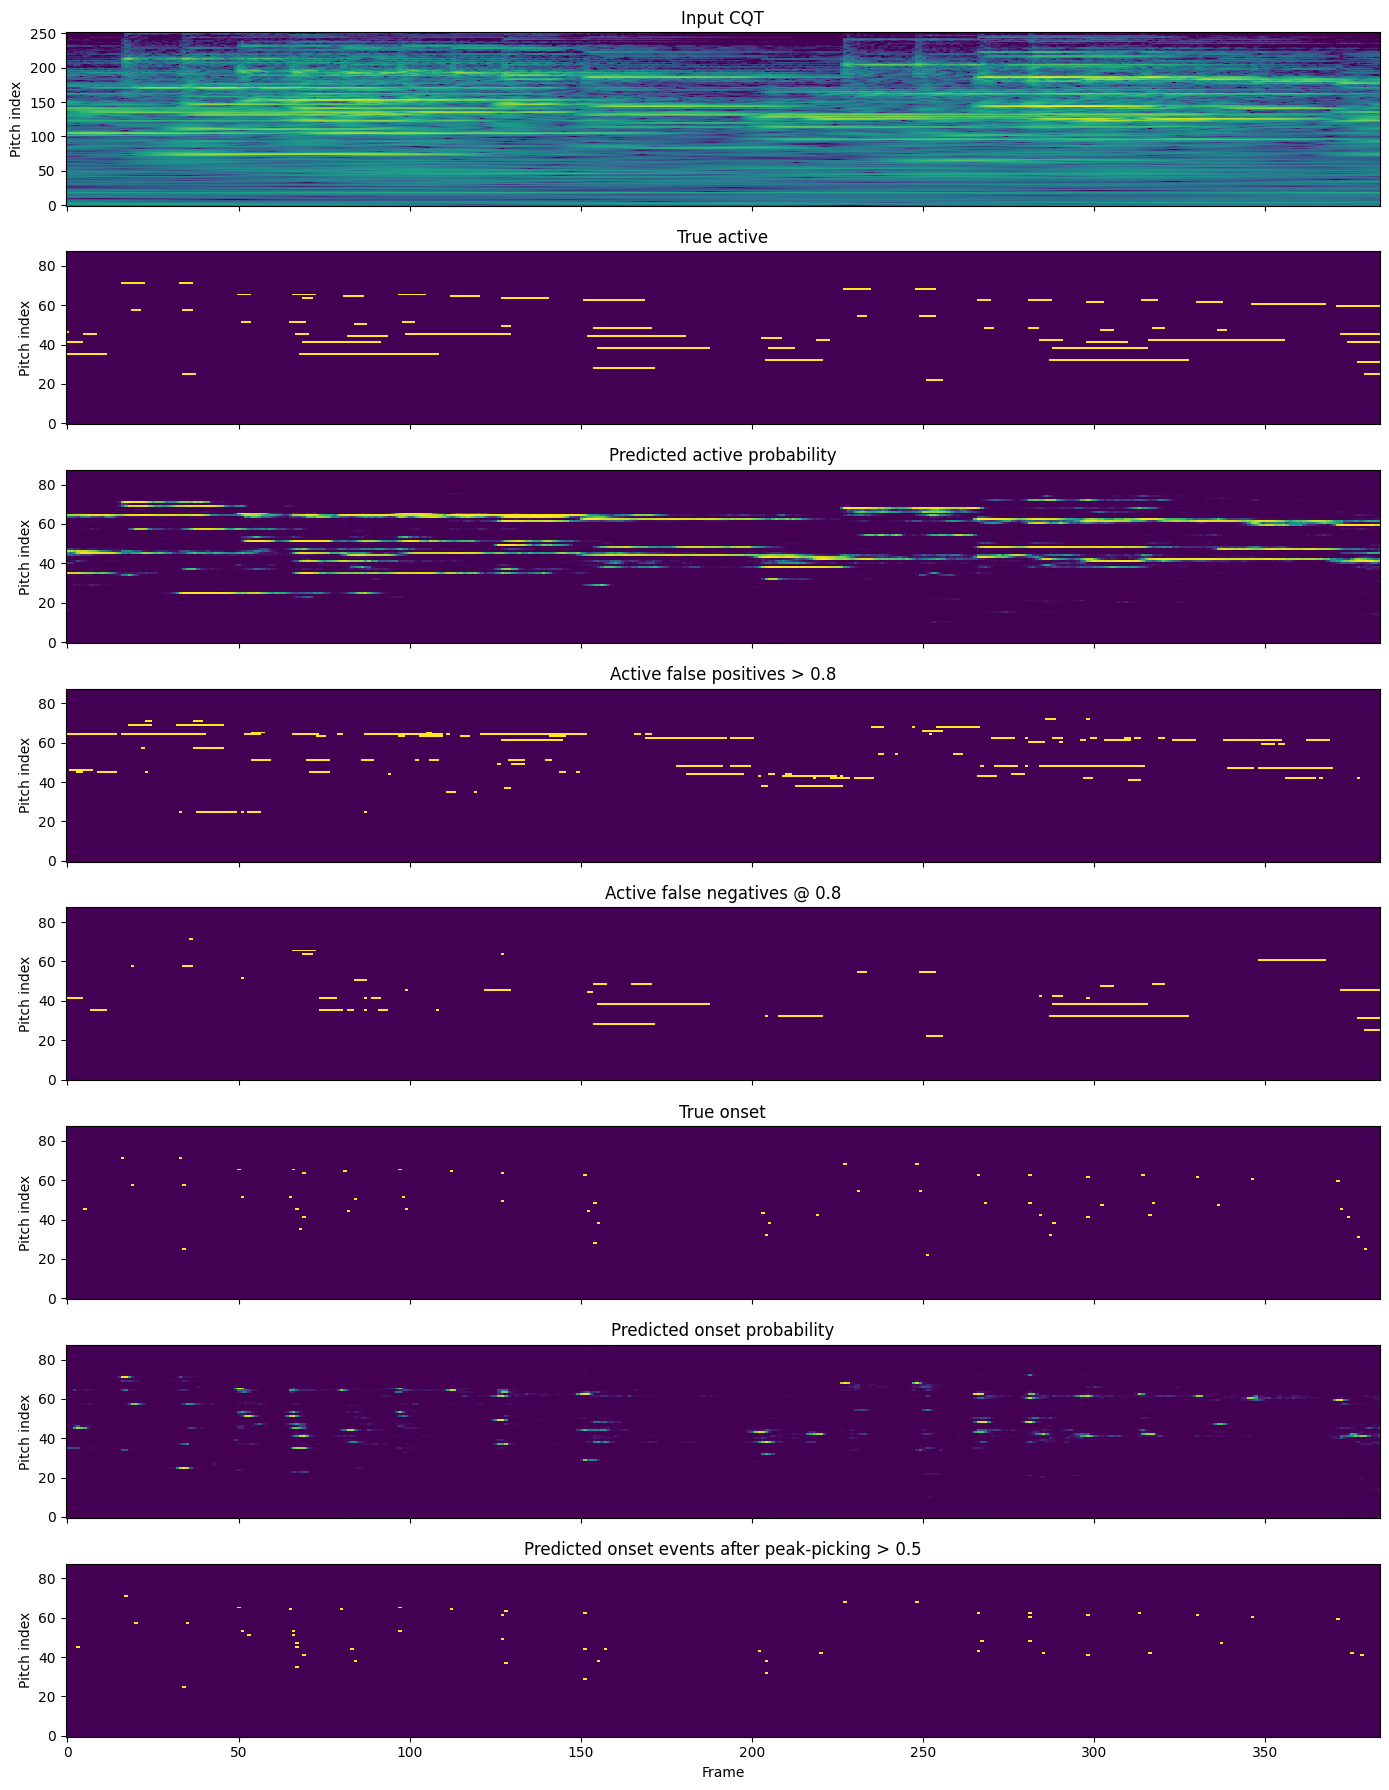

Pred active > threshold: 967
True active positives: 644
Active TP: 365
Active FP: 602
Active FN: 279

Pred onset events: 53
True onset positives: 58
Active FP distance to nearest true active pitch
count: 419
median: 7.0
mean: 10.422434367541767
distance  1: 17.90%
distance  2:  9.55%
distance  3:  0.95%
distance  4:  4.30%
distance  5:  6.92%
distance  6:  6.68%
distance  7:  5.01%
distance  8:  0.48%
distance  9:  0.24%
distance 10:  8.59%
distance 11:  1.67%
distance 12:  1.91%
distance 13:  2.86%
distance 14:  3.82%
distance 16:  0.48%
distance 18:  6.44%
distance 19:  7.64%
distance 20:  3.58%
distance 21:  0.24%
distance 22:  0.72%
distance 23:  2.39%
distance 24:  2.39%


{'pred_active': array([[2.34002876e-03, 1.96091854e-03, 3.21398511e-05, ...,
         1.15569821e-03, 1.55820628e-04, 2.42086928e-04],
        [1.44428472e-04, 1.92857580e-04, 2.14048941e-06, ...,
         1.68706640e-04, 5.78322106e-05, 1.34651157e-06],
        [1.77363356e-04, 4.74508088e-05, 5.90308559e-07, ...,
         3.09702707e-04, 7.35944996e-05, 2.23991719e-06],
        ...,
        [7.75101071e-04, 1.87247002e-03, 1.62563268e-07, ...,
         3.18987477e-05, 5.28923774e-05, 6.53879033e-06],
        [1.58560125e-03, 1.11375574e-03, 2.64026795e-07, ...,
         9.50978065e-05, 8.17732143e-05, 2.54893530e-06],
        [3.17884460e-02, 6.57352153e-03, 1.49793095e-05, ...,
         1.56864896e-03, 4.43696772e-04, 1.51277447e-04]],
       shape=(384, 88), dtype=float32),
 'pred_onset': array([[3.37408273e-04, 5.74352271e-05, 1.32805394e-06, ...,
         2.12350697e-05, 7.41748445e-05, 2.10934718e-06],
        [1.56667884e-04, 3.82112157e-05, 2.85936312e-06, ...,
         3.4295

In [44]:
plot_prediction_vs_target(
    model,
    val_dataset,
    idx=2,
    device=DEVICE,
)

# Save model

In [41]:
def save_checkpoint(
    path,
    model,
    optimizer,
    epoch,
    config: dict,
):
    raw_model = model.module if isinstance(model, torch.nn.DataParallel) else model

    torch.save({
        "epoch": epoch,
        "model_state_dict": raw_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "config": config,
    }, path)

save_checkpoint(
    "overfit_debug_checkpoint.pt",
    model,
    optimizer,
    epoch=10,
    config={
        "d_model": D_MODEL,
        "n_heads": N_HEADS,
        "n_layers": N_LAYERS,
        "chunk_frames": CHUNK_FRAMES,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "active_pos_weight": active_pos_weight,
        "onset_pos_weight": onset_pos_weight,
        "onset_loss_weight": onset_loss_weight,
        "onset_widen_radius": 1,
        "n_bins": N_BINS,
        "n_pitches": N_PITCHES,
    },
)

In [42]:
checkpoint = torch.load("overfit_debug_checkpoint.pt", map_location=DEVICE)

model = PianoTranscriber(
    d_model=checkpoint["config"]["d_model"],
    n_heads=checkpoint["config"]["n_heads"],
    n_layers=checkpoint["config"]["n_layers"],
    max_frames=checkpoint["config"]["chunk_frames"],
).to(DEVICE)

model.load_state_dict(checkpoint["model_state_dict"])

TypeError: PianoTranscriber.__init__() got an unexpected keyword argument 'max_frames'

# Evaluate performance

In [ ]:
raise ValueError

In [ ]:
results = evaluate_one_item_thresholds(
    model,
    val_dataset,
    idx=0,
    device=DEVICE,
    thresholds=(0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99),
    onset_frame_tolerance=1,
)

# Midi Conversion

In [ ]:
def load_model_from_checkpoint(model, checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device)

    # Handles both common checkpoint styles:
    # 1. torch.save(model.state_dict(), path)
    # 2. torch.save({"model_state_dict": model.state_dict(), ...}, path)
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        state_dict = ckpt["model_state_dict"]
    elif isinstance(ckpt, dict) and "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
    else:
        state_dict = ckpt

    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model



def peak_pick_onsets(
    onset_prob: np.ndarray,       # (T, 88)
    threshold: float = 0.5,
    pre_max: int = 1,
    post_max: int = 1,
    min_gap_frames: int = 3,
):
    """
    Converts onset probabilities into a sparse onset boolean matrix.

    Keeps only local maxima along time for each pitch.

    onset_prob: (T, 88)
    returns:    (T, 88) bool
    """
    T, P = onset_prob.shape
    peaks = np.zeros_like(onset_prob, dtype=bool)

    for p in range(P):
        y = onset_prob[:, p]

        candidates = []

        for t in range(T):
            left = max(0, t - pre_max)
            right = min(T, t + post_max + 1)

            is_high_enough = y[t] >= threshold
            is_local_max = y[t] == y[left:right].max()

            if is_high_enough and is_local_max:
                candidates.append(t)

        # Non-maximum suppression: keep strongest peaks separated by min_gap_frames
        candidates = sorted(candidates, key=lambda t: y[t], reverse=True)

        kept = []
        for t in candidates:
            too_close = any(abs(t - kt) < min_gap_frames for kt in kept)
            if not too_close:
                kept.append(t)

        for t in kept:
            peaks[t, p] = True

    return peaks
    
@torch.no_grad()
def predict_sample(model, dataset, sample_idx, device):
    X, Y_true = dataset[sample_idx]

    # X is usually (T, N_BINS). Batch it to (1, T, N_BINS).
    if not torch.is_tensor(X):
        X = torch.from_numpy(X)

    X = X.float().unsqueeze(0).to(device)

    logits = model(X)
    probs = torch.sigmoid(logits)

    # Return first batch item back on CPU.
    return probs[0].cpu().numpy(), Y_true


@torch.no_grad()
def predict_to_label_matrix(
    model,
    X,
    device,
    active_threshold: float = 0.5,
    onset_threshold: float = 0.5,
    default_velocity: float = 0.8,
    use_peak_picking: bool = True,
):
    """
    Convert model output into a (T, 88, 3) matrix compatible with label_matrix_to_midi.

    Assumes model output channels are:
      channel 0 = active
      channel 1 = onset
    """
    model.eval()

    if not torch.is_tensor(X):
        X = torch.from_numpy(X)

    # X: (T, N_BINS) -> (1, T, N_BINS)
    X = X.float().unsqueeze(0).to(device)

    logits = model(X)
    probs = torch.sigmoid(logits)[0].cpu().numpy()  # (T, 88, 2)

    active_prob = probs[:, :, 0]
    onset_prob = probs[:, :, 1]

    if use_peak_picking:
        onset_binary = peak_pick_onsets(
            onset_prob,
            threshold=onset_threshold,
            pre_max=5,
            post_max=5,
            min_gap_frames=50,
        )

        # Optional but recommended: only allow onset if active is somewhat present
        onset_binary = onset_binary & (active_prob > 0.3)

        onset_out = onset_binary.astype(np.float32)
    else:
        onset_out = (onset_prob > onset_threshold).astype(np.float32)

    T = probs.shape[0]

    Y_pred = np.zeros((T, N_PITCHES, N_LABEL_CHANNELS), dtype=np.float32)

    # Depends on what label_matrix_to_midi expects:
    # If it expects probabilities, keep active as probability.
    # If it expects hard labels, use active_prob > active_threshold.
    Y_pred[:, :, CH_ACTIVE] = (active_prob > active_threshold).astype(np.float32)
    Y_pred[:, :, CH_ONSET] = onset_out

    # Constant dummy velocity
    Y_pred[:, :, CH_VEL] = default_velocity

    return Y_pred


In [ ]:
sample_idx = 2

X, Y_true = dataset[sample_idx]

Y_pred = predict_to_label_matrix(
    model=model,
    X=X,
    device=device,
    default_velocity=0.8,
)

pm_pred = label_matrix_to_midi(
    Y_pred,
    output_path="/kaggle/working/prediction_sample_004.mid",
    onset_threshold=0.5,
    active_threshold=0.5,
)

X, Y_true = dataset[sample_idx]

# If your dataset now stores Y as (T, 88, 2), adapt it too.
if torch.is_tensor(Y_true):
    Y_true = Y_true.cpu().numpy()

Y_true_3ch = np.zeros((Y_true.shape[0], N_PITCHES, N_LABEL_CHANNELS), dtype=np.float32)

Y_true_3ch[:, :, CH_ACTIVE] = Y_true[:, :, 0]
Y_true_3ch[:, :, CH_ONSET] = Y_true[:, :, 1]
Y_true_3ch[:, :, CH_VEL] = 0.8

label_matrix_to_midi(
    Y_true_3ch,
    output_path="/kaggle/working/ground_truth_sample_000.mid",
    onset_threshold=0.5,
    active_threshold=0.5,
)

In [ ]:
def binary_prf(y_true, y_pred):
    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)

    tp = np.logical_and(y_true, y_pred).sum()
    fp = np.logical_and(~y_true, y_pred).sum()
    fn = np.logical_and(y_true, ~y_pred).sum()

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
    }


def compare_label_matrices(
    Y_true,
    Y_pred,
    active_threshold=0.5,
    onset_threshold=0.5,
):
    true_active = Y_true[:, :, CH_ACTIVE] >= active_threshold
    pred_active = Y_pred[:, :, CH_ACTIVE] >= active_threshold

    true_onset = Y_true[:, :, CH_ONSET] >= onset_threshold
    pred_onset = Y_pred[:, :, CH_ONSET] >= onset_threshold

    return {
        "active": binary_prf(true_active, pred_active),
        "onset": binary_prf(true_onset, pred_onset),
        "true_active_frames": int(true_active.sum()),
        "pred_active_frames": int(pred_active.sum()),
        "true_onsets": int(true_onset.sum()),
        "pred_onsets": int(pred_onset.sum()),
    }



In [ ]:
for onset_th in [0.5, 0.6, 0.7, 0.8, 0.9]:
    metrics = compare_label_matrices(
        Y_true_3ch,
        Y_pred,
        active_threshold=0.5,
        onset_threshold=onset_th,
    )
    print("onset_th:", onset_th, metrics["onset"])